In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
import cmath
from tqdm import tqdm
from matplotlib.colors import LogNorm
import datetime
import pytz
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import itertools
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
# ut.set_fig_font() ### Set various sizes in plotting
import pandas as pd
import scipy as sp
from multiprocessing import Pool
import qutip as qt
import multiprocessing as mp

In [2]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
E_C

0.20012190476190478

## Prepare two zero pi 

In [3]:
truc1, truc_tot, charge_pick = 80, 500, True
amp_bound, detune_bound, tg_bound = [(0, 0.5), (-1, 1), (-0.01, 0.01)]
tg_vec = np.arange(20, 210, 40).tolist() # np.array([20, 100, 200])
workers, popsize = 120, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]
drive_ab = False

logic_states = ['0-0', '0-2', '2-0', '2-2']
# args_all = ut.get_operator_two_zeropi_v2(truc1=truc1, truc_tot=truc_tot, charge_pick=charge_pick)
# [hspace_0, hspace_1, top3_index, top3_overlap,
# n_theta0_dress, n_theta1_dress, eval_tot, hspace_full] = args_all


In [4]:
folder = 'data/two_qubit_data_truc1=80_truc2=500_pick=True/'
# pd.DataFrame(n_theta0_dress).to_csv(folder+ 'n_theta0_dress.txt', sep=',', index=False, header=True)
# pd.DataFrame(n_theta1_dress).to_csv(folder+ 'n_theta1_dress.txt', sep=',', index=False, header=True)
# pd.DataFrame(eval_tot).to_csv(folder+ 'eval_tot.txt', sep=',', index=False, header=True)
# pd.DataFrame(hspace_full).to_csv(folder+ 'hspace_full.txt', sep=',', index=False, header=True)
# pd.DataFrame(hspace_0).to_csv(folder+ 'hspace_0.txt', sep=',', index=False, header=True)
# pd.DataFrame(hspace_1).to_csv(folder+ 'hspace_1.txt', sep=',', index=False, header=True)
# pd.DataFrame(top3_index).to_csv(folder+ 'top3_index.txt', sep=',', index=False, header=True)
# pd.DataFrame(top3_overlap).to_csv(folder+ 'top3_overlap.txt', sep=',', index=False, header=True)

eval_tot = pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
n_theta0_dress = pd.read_csv(folder+ 'n_theta0_dress.txt').to_numpy()
n_theta1_dress = pd.read_csv(folder+ 'n_theta1_dress.txt').to_numpy()
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()

hspace_0 = pd.read_csv(folder+ 'hspace_0.txt').to_numpy().flatten()
hspace_1 = pd.read_csv(folder+ 'hspace_1.txt').to_numpy().flatten()
top_index = pd.read_csv(folder+ 'top_index.txt')
top_overlap = pd.read_csv(folder+ 'top_overlap.txt').to_numpy()
len(hspace_full)

500

In [ ]:

# hspace_truc = ['0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
# '5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
# '1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
# '8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
# '0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
# '4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '24-0', '0-25' ,
# '15-1', '0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0' ,
# '13-2', '1-18', '15-2', '0-28', '5-9', '4-12', '0-30', '18-1', '12-4', '9-5' ,
# '1-20', '1-21', '0-33', '8-8', '0-34', '0-35', '1-24', '2-18', '0-36', '4-13' ,
# '22-1', '4-16', '5-12', '15-4', '24-1', '33-0', '2-20', '18-2', '2-21', '8-9' ,
# '1-25', '9-8', '1-26', '0-39', '12-5', '2-24', '5-13', '20-2', '5-16', '22-2' ,
# '13-5', '0-42', '15-5', '4-18', '2-25', '2-26', '8-12', '9-9', '0-44', '12-8' ,
# '1-30', '0-45', '4-21', '0-46', '1-33', '4-24', '5-18', '1-34', '1-35', '15-8' ,
# '1-36', '9-12', '24-4', '12-9', '33-1', '18-5', '2-30', '0-52', '46-0', '5-20' ,
# '4-25', '5-21', '4-26', '2-33', '9-13', '1-39', '37-1', '5-24', '9-16', '2-34' ,
# '2-35', '0-54', '2-36', '15-9', '0-55', '0-57', '5-25', '5-26', '0-59', '2-39' ,
# '1-45', '9-18', '4-33', '2-42', '0-65', '13-16', '9-20', '8-25', '2-44', '15-16' ,
# '9-21', '5-30', '20-9', '2-45', '9-24', '2-46', '5-33', '4-39', '0-68', '5-34' ,
# '5-35', '5-36', '0-73', '2-52', '2-53', '9-26', '0-78', '5-39', '18-16', '2-54' ,
# '4-44', '2-55', '2-57', '5-42', '2-59', '2-60', '5-44', '8-39', '9-33', '5-45'
# ]
# truc_index = [hspace_full.index(i) for i in hspace_truc]
# truc_len = len(hspace_truc)
# H0_truc = ut.truncate_2( H0_full, truc_index)
# drive_truc = ut.truncate_2(drive_term, truc_index)
# H_drive_truc = [H0_truc, [2*np.pi* drive_truc, ut.drive_gauss_A] ]
# logic_idx_truc = [hspace_truc.index(i) for i in logic_states]

In [6]:
print(len(hspace_full))

500


### get fidelity given params

In [ ]:
W_20_50 = 2*np.pi* ( eval_tot[hspace_full.index('5-0')] - eval_tot[hspace_full.index('2-0')] )
drive_term = n_theta0_dress + n_theta1_dress  if drive_ab else n_theta1_dress
H0_full = 2*np.pi* qt.Qobj(np.diag(eval_tot))
H_drive_full = [H0_full, [2*np.pi* qt.Qobj(drive_term), ut.drive_gauss_A] ]
logic_idx_full = [hspace_full.index(i) for i in logic_states]

[tg, drive_amp, detune ] =  [89.953852, 0.017468, 0.025304]
n_cpu_full = 50
r_tg = 1
tlist = np.linspace(0, tg, num=int(r_tg*tg)+1)  # total time
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_20_50 + 2*np.pi*detune,
            'gate_time': tg}
arg_all = [tg, drive_amp, detune, n_cpu_full, hspace_full, W_20_50, H_drive_full, logic_idx_full]
fidelity = ut.cz_fidelity(arg_all)
print('\ntruc1=', truc1, ', truc_tot=', truc_tot, ', charge_pick=', charge_pick)
print('fidelity = %.4f'%fidelity, 'or %.4f'%(1-10**fidelity))


truc1= 80 , truc_tot= 2000 , charge_pick= False
fidelity = -2.8359 or 0.9985


: 

### CZ_population

In [11]:
options = qt.Options(store_states=True)
result = {}
state_tot = [qt.basis(len(eval_tot), i) for i in range(len(eval_tot))]
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_full,
            qt.basis(len(eval_tot), hspace_full.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,options=options  )

2it [00:12,  6.47s/it]
2it [00:12,  6.23s/it]


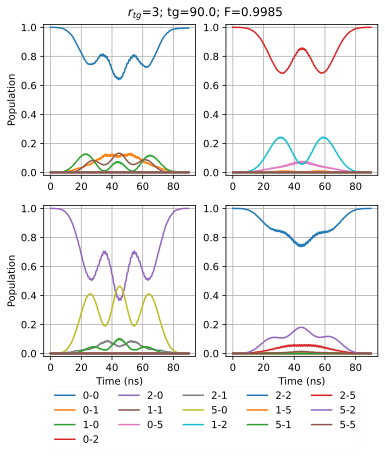

In [40]:
#####################################################################################
##### Drive and Population Visualization #######
state_good = ['0-1', '1-0', '1-1',
              '0-5', '1-2', '1-5',
              '5-0', '2-1', '5-1',
              '2-5', '5-2', '5-5']
fig, ax = plt.subplots(figsize=(6,6), nrows=2, ncols=2)
fig.suptitle('$r_{tg}$=%d'%r_tg+ '; tg=%.1f'%tg+ '; F=%.4f'%(1-10**fidelity), y=0.92)
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            if kdx in logic_states + state_good:
                ax[idx][jdx].plot(tlist, res,  label=r"%s" %kdx)
            # ax[idx][jdx].plot(tlist, res,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
# ax[1][1].legend(handles[::-1],labels[::-1], ncol=8,
# ax[1][1].legend(handles,labels, ncol=8,
#             loc='upper center', bbox_to_anchor=(0., -0.2)).get_frame().set_alpha(0.1)
fig.legend(handles,labels, ncol=5,
            loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)
# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

In [3]:
# dim = 10
# print('lowest dressed states :')
# data = index_state
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, data[i:i+dim] )), ',')

# print(len(eval_tot), len(index_state))
# dim = 10
# print('hilbert_space_0 :')
# data = hspace_0
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, data[i:i+dim] )), ',')
# print('hilbert_space_1 :')
# data = hspace_1
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, data[i:i+dim] )), ',')

In [4]:
state_all_200 = ['0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '0-9', '2-4', '9-0' ,
'1-5', '5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '0-13', '0-16' ,
'8-1', '4-4', '13-0', '15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5' ,
'0-18', '2-9', '1-12', '0-20', '0-21', '18-0', '9-2', '12-1', '5-5', '0-24' ,
'4-8', '1-13', '20-0', '8-4', '1-16', '22-0', '2-12', '13-1', '24-0', '0-25' ,
'15-1', '0-26', '5-8', '4-9', '12-2', '2-13', '9-4', '2-16', '8-5', '25-0' ,
'13-2', '1-18', '15-2', '0-28', '5-9', '4-12', '0-30', '18-1', '12-4', '9-5' ,
'1-20', '1-21', '0-33', '8-8', '0-34', '0-35', '1-24', '2-18', '0-36', '4-13' ,
'22-1', '4-16', '5-12', '15-4', '24-1', '33-0', '2-20', '18-2', '2-21', '8-9' ,
'1-25', '9-8', '1-26', '0-39', '12-5', '2-24', '5-13', '20-2', '5-16', '22-2' ,
'13-5', '0-42', '15-5', '4-18', '2-25', '2-26', '8-12', '9-9', '0-44', '12-8' ,
'1-30', '0-45', '4-21', '0-46', '1-33', '4-24', '5-18', '1-34', '1-35', '15-8' ,
'1-36', '9-12', '24-4', '12-9', '33-1', '18-5', '2-30', '0-52', '46-0', '5-20' ,
'4-25', '5-21', '4-26', '2-33', '9-13', '1-39', '37-1', '5-24', '9-16', '2-34' ,
'2-35', '0-54', '2-36', '15-9', '0-55', '0-57', '5-25', '5-26', '0-59', '2-39' ,
'1-45', '9-18', '4-33', '2-42', '0-65', '13-16', '9-20', '8-25', '2-44', '15-16' ,
'9-21', '5-30', '20-9', '2-45', '9-24', '2-46', '5-33', '4-39', '0-68', '5-34' ,
'5-35', '5-36', '0-73', '2-52', '2-53', '9-26', '0-78', '5-39', '18-16', '2-54' ,
'4-44', '2-55', '2-57', '5-42', '2-59', '2-60', '5-44', '8-39', '9-33', '5-45'
]


In [ ]:
# truc_index = [hilbert_space.index(i) for i in truc_state]
# truc_len = len(truc_index)

# H0 = ut.truncate_2(2* np.pi* qt.Qobj(np.diag(eval_tot)), truc_index)
# drive_truc = ut.truncate_2(drive_term, truc_index)

# state_tot = [qt.basis(truc_len, i) for i in range(truc_len)]
# logical_states = ['0-0', '0-2', '2-0', '2-2']
# hspace_index = [truc_state.index(i) for i in logical_states]
# state_logi = [state_tot[i] for i in hspace_index]

# W_20_50 = 2*np.pi* ( eval_tot[hilbert_space.index('5-0')] - eval_tot[hilbert_space.index('2-0')] )
# H_qbt_drive = [H0, [2*np.pi* drive_truc, ut.drive_gauss_A] ]

In [6]:
def sesolve_parallel(argz):
    H, psi0, tlist, pulse_args, options = argz
    return psi0, qt.sesolve(H, qt.basis(H[0].shape[0], psi0), tlist, options=options, args=pulse_args)

def cz_fidelity_fast(arg, *args):
    tg, drive_amp, detune = arg # Independent arguments that can be optimized over
    [n_cpu, drive_term, eval_tot, index_state, hilbert_space] = args # System arguments

    truc_index = [index_state.index(i) for i in hilbert_space]
    truc_len = len(hilbert_space)

    H0 = ut.truncate_2(2* np.pi* qt.Qobj(np.diag(eval_tot)), truc_index)
    drive_truc = ut.truncate_2(drive_term, truc_index)

    state_tot = [qt.basis(truc_len, i) for i in range(truc_len)]
    logical_states = ['0-0', '0-2', '2-0', '2-2']
    logical_idx = [hilbert_space.index(i) for i in logical_states]
    state_logi = [state_tot[i] for i in logical_idx]

    W_20_50 = 2*np.pi* ( eval_tot[index_state.index('5-0')] - eval_tot[index_state.index('2-0')] )
    H_qbt_drive = [H0, [2*np.pi* drive_truc, ut.drive_gauss_A] ]

    pulse_args = {'drive_amp_A': drive_amp,
                'drive_freq_A': W_20_50 + 2*np.pi*detune,
                'gate_time': tg}
    tlist = np.linspace(0, tg, num=int(tg))  # total time

    sesolve_args = []
    prop = np.zeros((len(hilbert_space), len(logical_states)), dtype=np.complex128)
    if n_cpu > 1:
        options = qt.Options(num_cpus=n_cpu, nsteps=1e4)
        for i in logical_idx:
            sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])
        pool = Pool(processes=n_cpu)
        for i, res in pool.imap_unordered(sesolve_parallel, sesolve_args):
            prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    else:
        options = qt.Options(num_cpus=5, nsteps=1e4)
        for i in logical_idx:
            sesolve_args.append([H_qbt_drive, i, tlist, pulse_args, options])
        for se_arg in sesolve_args:
            i, res = sesolve_parallel(se_arg)
            prop[:, logical_idx.index(i)] = res.states[-1].full().flatten()
    prop = qt.Qobj(prop)
    Uc = ut.truncate_2(prop, [hilbert_space.index(psi) for psi in logical_states])

    Uz = ut.remove_global_phase(qt.tensor( rz(ut.dphi(Uc, (2,2))),
                                        rz(ut.dphi(Uc, (1,1)))))
    Uc_reshaped = qt.Qobj(Uc.data, dims=[[2, 2], [2, 2]])
    Ucprime = ut.remove_global_phase(Uz * Uc_reshaped)
    fidelity = qt.average_gate_fidelity(Ucprime, target=cz_gate())
    return np.log10(1-fidelity)

#### Get fidelity

In [9]:
hilbert_space = state_all_200
drive_term = n_theta1_dress
n_cpu = 1
truc1, truc_tot = 30, 45
amp_bound, detune_bound, tg_bound = [(0, 0.5), (-0.5, 0.5), (-0.1, 0.1)]
tg_vec = np.array([20, 100])
workers, popsize = 60, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]


In [10]:
fidelity = []
drive_param = []
fidelity_full = []
args = [n_cpu, drive_term, eval_tot, index_state, hilbert_space]
for jdx, tg in tqdm(enumerate(tg_vec)):
# for jdx, tg in tqdm(enumerate(x0_vec[:,0])):
    tg_bounds = (tg+tg_bound[0], tg+tg_bound[1])
    bounds = (tg_bounds, amp_bound, detune_bound)
    res = sp.optimize.differential_evolution(
        func=cz_fidelity_fast,
        bounds=bounds,
        args=args,
        disp=True,
        callback=ut.print_soln,
        init="sobol",
        workers=workers,
        popsize=popsize,
        mutation=mutation,
        recombination=recombination,
        tol=tol,
        # x0=x0_vec[jdx],
        polish=False, # 'True' will make the for-loop break
        )
    fidelity.append(res.fun)
    drive_param.append(res.x)

    print(res, '\n')
    print('\ntg = ', np.array(tg_vec[:jdx+1]).tolist())

    print(f'\nlog of gate error (truc1={truc1}) = ')
    for i in range(0, len(fidelity), 4):
        print(', '.join(map(str, np.round(fidelity[i:i+4], 8))), ',')

    print(f'\ndrive_param (truc1={truc1}) = ')
    for i in drive_param:
        print(np.round(i,6).tolist(),',')

0it [00:00, ?it/s]

differential_evolution step 1: f(x)= -0.275063
Best Soln: [2.00754247e+01 2.18108129e-05 5.29970616e-02]
convergence 0.0271
----------------------------
differential_evolution step 2: f(x)= -0.275063
Best Soln: [2.00754247e+01 2.18108129e-05 5.29970616e-02]
convergence 0.0262
----------------------------
differential_evolution step 3: f(x)= -0.275063
Best Soln: [2.00754247e+01 2.18108129e-05 5.29970616e-02]
convergence 0.0304
----------------------------
differential_evolution step 4: f(x)= -0.275602
Best Soln: [2.00799913e+01 1.54295457e-03 2.22042576e-02]
convergence 0.0322
----------------------------
differential_evolution step 5: f(x)= -0.281623
Best Soln: [2.00942369e+01 1.05519265e-03 1.76581015e-02]
convergence 0.034
----------------------------
differential_evolution step 6: f(x)= -0.281623
Best Soln: [2.00942369e+01 1.05519265e-03 1.76581015e-02]
convergence 0.0374
----------------------------
differential_evolution step 7: f(x)= -0.286201
Best Soln: [2.00969081e+01 2.5683116

1it [01:23, 83.54s/it]

differential_evolution step 16: f(x)= -0.289523
Best Soln: [2.00758594e+01 2.89921379e-03 1.93929513e-02]
convergence 1.0811
----------------------------
 message: Optimization terminated successfully.
 success: True
     fun: -0.2895227844971844
       x: [ 2.008e+01  2.899e-03  1.939e-02]
     nit: 16
    nfev: 544 


tg =  [20]

log of gate error (truc1=30) = 
-0.28952278 ,

drive_param (truc1=30) = 
[20.075859, 0.002899, 0.019393] ,


1it [01:43, 103.68s/it]


KeyboardInterrupt: 

In [ ]:
arg = [20, -0.00079341, 0.07453565] # tg, detune, drive_amp
f = ut.cz_fidelity_parallel(arg, *args)
f

-0.14659167012803312

In [ ]:
arg = [100, -0.31959610, 0.03429656] # tg, detune, drive_amp
f300 = ut.cz_fidelity_parallel(arg, *args)
f300

-0.2908212273975405

#### Optimize

In [ ]:
tg_vec = [20, 100] #np.linspace(40, 56, num=3)
detune_bound, amp_bound = (-0.5, 0.5), (0, 0.5)
arg = (detune_bound, amp_bound)
workers, popsize = 160, 20
mutation, recombination, tol = (0.5, 1.99), 0.7, 0.01

In [ ]:
def fidelity_sweep():
    fidelity = []
    drive_param = []
    for jdx, tg in tqdm(enumerate(tg_vec)):
        args = [H_qbt_drive, W_target, state_logi, tg]
        res = sp.optimize.differential_evolution(
            func=ut.cz_fidelity_optimize,
            bounds=arg,
            args=args,
            disp=True,
            callback=ut.print_soln,
            init="sobol",
            workers=workers,
            popsize=popsize,
            mutation=mutation,
            recombination=recombination,
            tol=tol,
            polish=False, # 'True' will make the for-loop break
            )
        fidelity.append(res.fun)
        drive_param.append(res.x.tolist())
        print(res, '\n')
        print('\ntg = ', np.array((tg_vec[:,0])[:jdx+1]).tolist())
        print('\nlog of gate error (truc=45) = ')
        for i in range(0, len(fidelity), 4):
            print(', '.join(map(str, np.round(fidelity[i:i+4], 8))), ',')
        print('\ndrive_param = ')
        for i in drive_param:
            print(np.round(i,6).tolist(),',')

In [ ]:
fidelity_sweep()

In [ ]:

truc = len(trunc_states)
state_tot = [qt.basis(truc, i) for i in range(truc)]
W_20_50 = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
idxs = [order_sort.index(i) for i in trunc_states]

In [ ]:
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
eta = - n2_22 / n1_22
W_target = W_20_50

### get propagator 

In [ ]:
drive_ab = False
[tg, fidelity, fidelity_qt, detune,drive_amp
 ] = [90.0,-3.28742709,-3.38933446,-0.04780261,0.02850925]

r_tg = 1.5
tlist = np.linspace(0, tg, num=int(r_tg*tg))  # total time


drive_term = n_theta1_truc + n_theta2_truc if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]

pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_target + 2*np.pi*detune,
            'gate_time': tg}
tlist = np.linspace(0, tg, num=int(tg))  # total time
prop = qt.propagator( H=H_qbt_drive,
                        t=tlist,
                        args=pulse_args,)[-1]  # get the propagator at the final time step

state_logi = state_tot[:4]
Uz = ut.remove_global_phase(qt.tensor( rz(ut.dphi(prop, (2,2))),
                                    rz(ut.dphi(prop, (1,1)))))

Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
        for s2 in state_logi  ])
Uc_reshaped = qt.Qobj(Uc.data, dims=[[2, 2], [2, 2]])
Ucprime = ut.remove_global_phase(Uz * Uc_reshaped)
qt.Qobj(np.round(Ucprime, 2))

Quantum object: dims = [[4], [4]], shape = (4, 4), type = oper, isherm = False
Qobj data =
[[ 1.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    1.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    1.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j   -1.+0.01j]]

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

: 

### CZ_dark_population

In [ ]:
drive_ab = True
args = [H0, n_theta1_truc, n_theta2_truc, eta, W_target, tg, state_tot, drive_ab]
[tg,fidelity,fidelity_qt,
 detuning,drive_amp,d_eta] = [140.0,-4.32373754,-4.41087759,-0.06893879,0.01700783,0.19847014]
# [90.0,-3.50187796,-3.56385284,-0.0429,0.0271,0.234]
arg_de = detuning, drive_amp, d_eta
fidelity = ut.get_fidelity_cz_dark(arg_de, *args)
print(fidelity, 1-10**fidelity)

-4.3237373077182095 0.9999525471072586


2it [00:00,  3.36it/s]
2it [00:00,  2.48it/s]


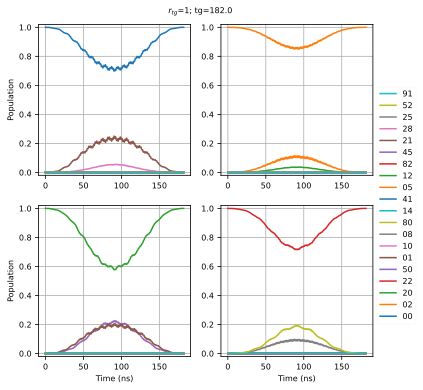

In [ ]:
options = qt.Options(store_states=True)
r_tg = 1.5
tlist = np.linspace(0, tg, num=int(r_tg*tg))  # total time
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_target + 2*np.pi*detuning,
            'gate_time': tg}

drive_term = n_theta2_truc + (eta+d_eta) * n_theta1_truc  if drive_ab else n_theta2_truc
H_qbt_drive = [H0, [2*np.pi* drive_term, ut.drive_gauss_A] ]
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc, trunc_states.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,options=options  )
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,6), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('$r_{tg}$=%d'%r_tg+ '; tg=%.1f'%tg, y=0.92)
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res,  label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

In [ ]:
transposed_list = list(zip(*result[1,0].expect))
df = pd.DataFrame(transposed_list, columns=trunc_states)
# df.to_csv('data/cz_dark_population_20.txt', sep=',', index=True, header=True)

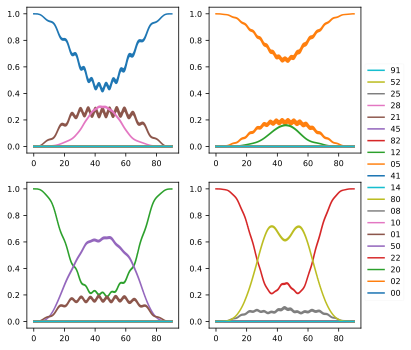

In [ ]:
df_00 = pd.read_csv('data/cz_dark_population_00.txt', index_col=0)
df_02 = pd.read_csv('data/cz_dark_population_02.txt', index_col=0)
df_20 = pd.read_csv('data/cz_dark_population_20.txt', index_col=0)
df_22 = pd.read_csv('data/cz_dark_population_22.txt', index_col=0)
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
for kdx, res in enumerate(trunc_states):
    ax[0][0].plot(tlist, df_00[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[0][1].plot(tlist, df_02[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[1][0].plot(tlist, df_20[res], label=r"%s" % res)
for kdx, res in enumerate(trunc_states):
    ax[1][1].plot(tlist, df_22[res], label=r"%s" % res)
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

#### cz_fidelity_sensivity

In [ ]:

detune_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product(detuning + detune_vec, [drive_amp], [d_eta]))
fidelity_wd = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

A_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product([detuning], drive_amp+A_vec, [d_eta]))
fidelity_A = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

eta_vec = np.linspace(-0.05, 0.05, 101)
values_grid = list(itertools.product([detuning], [drive_amp], d_eta+eta_vec))
fidelity_eta = Parallel(n_jobs=len(eta_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.2s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    2.1s finished


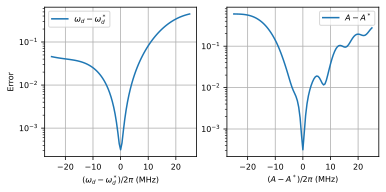

In [ ]:
error_vs_dwd = np.column_stack((np.round(10**3 * detune_vec, 2), np.round(fidelity_wd, 8)))
columns = ['dwd_vec(MHz)',  'error_wd']
df = pd.DataFrame(error_vs_dwd, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dwd.txt', sep=',', index=True, header=True)

# error_vs_A = np.column_stack((np.round(10**3 * A_vec, 2), np.round(fidelity_A, 8)))
# columns = ['dA_vec(MHz)',  'error_A']
# df = pd.DataFrame(error_vs_A, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dA.txt', sep=',', index=True, header=True)

# error_vs_eta = np.column_stack((np.round( eta_vec, 2), np.round(fidelity_eta, 8)))
# columns = ['eta_vec',  'error_A']
# df = pd.DataFrame(error_vs_eta, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_eta.txt', sep=',', index=True, header=True)

df_wd = pd.read_csv('data/cz_dark_tg90_error_vs_dwd.txt')
df_dA = pd.read_csv('data/cz_dark_tg90_error_vs_dA.txt')
df_eta = pd.read_csv('data/cz_dark_tg90_error_vs_eta.txt')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( df_wd['dwd_vec(MHz)'], 10**df_wd['error_wd'], '-', label='$\omega_{d} - \omega_{d}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d} - \omega_{d}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( df_dA['dA_vec(MHz)'], 10**df_dA['error_A'], '-', label='$A - A^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A - A^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

#### cz_fidelity_print

In [ ]:
df_cz_dark = pd.read_csv('data/data_cz_n1n2_20_dark.txt')
para = df_cz_dark[['tg','detuning', 'drive_amp', 'd_eta']].to_numpy()
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
eta = - n2_22 / n1_22
W_target = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
args = [H0, n_theta1_truc, n_theta2_truc, eta, W_target, state_tot, drive_ab]
fidelity_w1 = Parallel(n_jobs=80, verbose=1)(delayed(ut.get_fidelity_cz_dark_print)(arg_de, *args)
                                            for arg_de in para)

[Parallel(n_jobs=80)]: Using backend LokyBackend with 80 concurrent workers.
[Parallel(n_jobs=80)]: Done   4 out of  81 | elapsed:    3.9s remaining:  1.3min
[Parallel(n_jobs=80)]: Done  81 out of  81 | elapsed:    6.6s finished


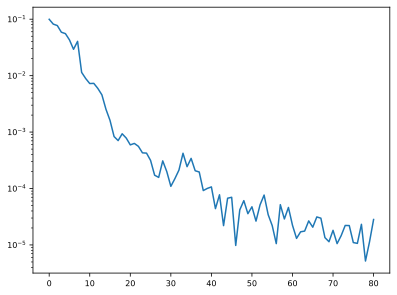

In [ ]:
plt.plot( 10**np.array(fidelity_w1))
plt.yscale('log')

### Jump operators

In [ ]:
gamma_2 =  1
gamma_p2 = 1.1
gamma_3 =  10
gamma_p3 =  11

idxs = [order_sort.index(i) for i in trunc_states]
trunc_dim = eket1.shape[0]
truc = len(trunc_states)
eket_truc = [eket_tot[i] for i in idxs]
eket_truc = np.reshape(eket_truc, (truc, trunc_dim**2))
jump_t1 = np.zeros((truc, truc), dtype=complex)
jump_tphi = np.zeros((truc, truc), dtype=complex)
for i in range(1,10):
    ladder_0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).dag()
    a_0i_I = qt.tensor(ladder_0i, qt.qeye(trunc_dim))
    a_I_0i = qt.tensor(qt.qeye(trunc_dim), ladder_0i)
    jump_t1_i = (eket_truc @ ( a_0i_I + a_I_0i ).data @ eket_truc.conj().T)

    proj_ii = qt.basis(trunc_dim,i).proj()
    a_ii_I = qt.tensor(proj_ii, qt.qeye(trunc_dim))
    a_I_ii = qt.tensor(qt.qeye(trunc_dim), proj_ii)
    jump_tphi_i = (eket_truc @ ( a_ii_I + a_I_ii ).data @ eket_truc.conj().T)

    if i == 1:
        jump_t1 += np.sqrt(gamma_2)* jump_t1_i
        jump_tphi += np.sqrt(2*gamma_p2) * jump_tphi_i
    else:
        jump_t1 += np.sqrt(gamma_3)* jump_t1_i
        jump_tphi += np.sqrt(2*gamma_p3) * jump_tphi_i
jump_t1 = qt.Qobj(jump_t1)
jump_tphi = qt.Qobj(jump_tphi)

In [ ]:
jump_t1.tidyup(atol=1e-3)

In [ ]:
eket_truc = np.reshape([eket_tot[i] for i in idxs], (truc, eket1.shape[0]**2))
jump_op_t1 = np.zeros((truc, truc), dtype=complex)
jump_op_tphi = np.zeros((truc, truc), dtype=complex)
for state in trunc_states[1:]:
    a0i = eket0[0].conj().T @ eket0[int(state[0])]
    a0i = eket0 @ a0i @ eket0.conj().T

    b0j = eket1[0].conj().T @ eket1[int(state[1])]
    b0j = eket1 @ b0j @ eket1.conj().T

    jump_op_t1 += (eket_truc @ np.kron(a0i, b0j) @ eket_truc.conj().T)

    aii = eket0[int(state[0])].conj().T @ eket0[int(state[0])]
    aii = eket0 @ aii @ eket0.conj().T
    bjj = eket1[int(state[1])].conj().T @ eket1[int(state[1])]
    bjj = eket1 @ bjj @ eket1.conj().T
    eket_truc = np.reshape([eket_tot[i] for i in idxs], (truc, eket1.shape[0]**2))
    jump_op_tphi += (eket_truc @ np.kron(aii, bjj) @ eket_truc.conj().T)

jump_op_t1 = qt.Qobj(jump_op_t1) * np.sqrt(gamma_2)
jump_op_tphi = qt.Qobj(jump_op_tphi) * np.sqrt(2*gamma_p2)

In [ ]:
for i in range(1,10):
    proj_0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).trans()
    a_0i_I = qt.tensor(proj_0i, qt.qeye(trunc_dim))
    a_I_0i = qt.tensor(qt.qeye(trunc_dim), proj_0i)
    jump_op_t1 += (eket_truc @ (a_0i_I+a_I_0i).data @ eket_truc.conj().T)

In [ ]:
trunc_dim=10
i = 2
jump_op_t1 = np.zeros((truc, truc), dtype=complex)
a0i = qt.basis(trunc_dim,0) * qt.basis(trunc_dim,i).trans()
a0i_I = qt.tensor(a0i, qt.qeye(trunc_dim))
truc = len(trunc_states)

idxs = [order_sort.index(i) for i in trunc_states]
eket_truc_ = [eket_tot[i] for i in idxs]

eket_truc = np.reshape(eket_truc_, (truc, eket1.shape[0]**2))
jump_op_t1 += (eket_truc @ a0i_I.data @ eket_truc.conj().T)

In [ ]:
aaa = eket_truc @ a0i_I.data @ eket_truc.conj().T
qt.Qobj(aaa).tidyup()

In [ ]:
W_20_50 = np.abs(ut.transition_frequency(order_sort.index('20') , order_sort.index('50'), eval_tot))
W_22_52 = np.abs(ut.transition_frequency(order_sort.index('22') , order_sort.index('52'), eval_tot))
W_00_01 = np.abs(ut.transition_frequency(order_sort.index('00') , order_sort.index('01'), eval_tot))
print('W_20_50 = ', W_20_50)
print('W_22_52 = ', W_22_52)
print('W_00_01 = ', W_00_01)

# $n_1$

In [ ]:
pa_n1_20 = np.array([
[0.008072686456606392, 0.04026375737128161] ,
[-0.026219601321467435, 0.03347232582603614] ,
[-0.02202195079756271, 0.033013355739382855] ,
[-0.016756585664457656, 0.032666722845291415] ,
[-0.04344759711916364, 0.04250115530326112] ,
[-0.03417453085487561, 0.02852661965341828] ,
[-0.05592196919398325, 0.027154584089242303] ,
[-0.06927884371923036, 0.02552444134031194] ,
[-0.0782223229229982, 0.023952079273604765] ,
[-0.08492264563797776, 0.02260733739522744] ,
[-0.09043608129578162, 0.021402615114334958] ,
[-0.0948748919345315, 0.02040860805971144] ,
[-0.06439548436267327, 0.01791412478285352] ,
[-0.051329319904350725, 0.016544314109077654] ,
[-0.07479113712020069, 0.016622117311335602] ,
[-0.06240366099366179, 0.015627679870857267] ,
[-0.07482559632905487, 0.015383632557276844] ,
[-0.07817427813765594, 0.014922812201150465] ,
[-0.0816530876863822, 0.014506148557486623] ,
[-0.07799399018212241, 0.013996446502301335] ,
[-0.10438070431150062, 0.01433503600913491] , ])
wd_n1_20 = W_20_50 + 2*np.pi* pa_n1_20[:,0]
wd_n1_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
pa_n1_00 = np.array([
[0.09998808220970042, 0.03389647651371554] ,
[0.0999984183445914, 0.03334010208960135] ,
[0.09997059222517883, 0.03279977063159997] ,
[0.09999979127031018, 0.03240779521344887] ,
[0.09069326060862769, 0.04249471582468528] ,
[0.09999883376243134, 0.028511124810695107] ,
[0.07852650155524495, 0.02715111899031597] ,
[0.06520853187760449, 0.025526509160756373] ,
[0.05635106791185157, 0.023967894419161053] ,
[0.04952288298843699, 0.022599052185279273] ,
[0.04407690405035916, 0.0214162618751392] ,
[0.03963968945578836, 0.02040976507375857] ,
[0.07013262402538958, 0.017915752743077988] ,
[0.08315083843208453, 0.016543318108878817] ,
[0.05968069601166326, 0.01662038788855584] ,
[0.07208559720557661, 0.015629110241698066] ,
[0.05964304998313631, 0.015384156071309996] ,
[0.05629629891946006, 0.014923140160711432] ,
[0.05286917059620126, 0.014508309607604242] ,
[0.05651959921673, 0.013995538320386691] ,
[0.05319666279212992, 0.013654384111454164] ,])
wd_n1_00 = W_00_01 + 2*np.pi* pa_n1_00[:,0]
wd_n1_00

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_00, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
wd_n1_00 - wd_n1_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n1_00 - wd_n1_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

# $n_2$

In [ ]:
pa_n2_22 = np.array([
[-0.12543802569960816, 0.0417916249940949] ,
[-0.11217803745503305, 0.04035183812339457] ,
[-0.11344293487232537, 0.03890386553456274] ,
[-0.090211249885337, 0.033132072771376725] ,
[-0.07533424625136681, 0.03194918518996296] ,
[-0.049438847578870106, 0.03244666627228647] ,
[-0.03946693548577948, 0.029848904264211502] ,
[-0.032237993210102935, 0.02833364697438628] ,
[-0.030966964969908684, 0.023299092937162036] ,
[-0.02768011827803043, 0.021835308173616525] ,
[-0.02464472841898352, 0.02074834657263286] ,
[-0.021803591735934012, 0.019882448116312335] ,
[-0.05167485874463183, 0.017164989142259113] ,
])
wd_n2_22 = W_22_52 + 2*np.pi* pa_n2_22[:,0]
wd_n2_22

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec[:13], wd_n2_22, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d$')
plt.grid()

In [ ]:
pa_n2_20 = np.array([
[-0.13489599, 0.04179519, 40.0, -0.81624313, -0.907084508] ,
[-0.12181585, 0.04033307, 48.0, -1.19868667, -1.25989732] ,
[-0.12313573, 0.03890629, 56.0, -1.75946055, -1.84931348] ,
[-0.0999998, 0.03313089, 64.0, -2.02348833, -2.11675684] ,
[-0.08518001, 0.03195758, 72.0, -2.32853766, -2.40378253] ,
[-0.0592095, 0.03243396, 80.0, -2.77269572, -2.85114121] ,
[-0.04928258, 0.02983801, 88.0, -2.87563305, -2.96970408] ,
[-0.04204181, 0.02832025, 96.0, -3.17013305, -3.27095058] ,
[-0.0388998, 0.03360252, 104.0, -3.33643771, -3.41646289] ,
[-0.03302637, 0.03087338, 112.0, -3.96625603, -4.04182622] ,
[-0.03441918, 0.02076661, 120.0, -3.656008, -3.77688879] ,
[-0.03160199, 0.01988816, 128.0, -4.0020057, -4.05923737] ,
# [-0.06150659, 0.01716301, 136.0, -3.75665887, -3.84597613] ,
[0.01072869, 0.01027827, 136.0, -4.70101245, None] ,
[-0.07902074, 0.01669434, 144.0, -4.1266732, -4.2136726] ,
[-0.09328667, 0.01585009, 152.0, -4.9369254, -4.98919321] ,
[-0.03546228, 0.01548912, 160.0, -4.45320218, -4.50990195] ,
[-0.06497353, 0.01494088, 168.0, -4.37817473, -4.4601287] ,
[-0.06167765, 0.01445689, 176.0, -4.24686447, -4.33405505] ,
[-0.05889779, 0.01401448, 184.0, -4.42871367, -4.50736131] ,
[-0.05619229, 0.01360428, 192.0, -4.41433082, -4.48947091] ,
[-0.06017003, 0.01330778, 200.0, -4.39312433, -4.46197193] ,
])
wd_n2_20 = W_20_50 + 2*np.pi* pa_n2_20[:,0]
wd_n2_20

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec, wd_n2_20, '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d$')
plt.grid()

In [ ]:
tg_vec = np.linspace(40, 200, num=21)
fig, ax = plt.subplots(figsize=(8,1.5))
plt.plot(tg_vec[:13], wd_n2_22 - wd_n2_20[:13], '.')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title('$\omega_d^{n_1-00} - \omega_d^{n_1-20}$')
plt.grid()

In [ ]:
=

In [ ]:
n1_22 = n_theta1_truc[trunc_states.index('22'), trunc_states.index('52')]
n2_22 = n_theta2_truc[trunc_states.index('22'), trunc_states.index('52')]
n1_20 = n_theta1_truc[trunc_states.index('20'), trunc_states.index('50')]
n2_20 = n_theta2_truc[trunc_states.index('20'), trunc_states.index('50')]
print(n1_22, n2_22, n1_20, n2_20)

eta = n1_22/n2_22
A_20 = n1_20 - eta* n2_20
print('eta = ', eta)
print('A_20 = ', A_20)